# Seccion 1 - TTR - MATTR

In [4]:
# =====================================================================
# 1. INSTALACIÓN DE DEPENDENCIAS Y CONFIGURACIÓN
# =====================================================================

!python -m spacy download es_core_news_sm > /dev/null
import spacy
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Configuración estética de los gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['figure.dpi'] = 100

nlp = spacy.load("es_core_news_sm")

In [5]:
# =====================================================================
# 2. CREACIÓN DEL TEXTO DE EJEMPLO (ESTILO BOLETÍN OFICIAL)
# =====================================================================
texto_boletin = """
Visto el expediente electrónico N° 45.234, y considerando que es necesario dictar la norma complementaria.
El Poder Ejecutivo nacional decreta la inmediata aprobación del presupuesto anual. Este decreto establece
que los decretos anteriores quedan derogados. El secretario decretó que se notificará el decreto a los
organismos correspondientes. Por cuanto, los decretos de necesidad y urgencia regulan el gasto público.
Se procede a la firma del presente decreto regulatorio en la ciudad de Salta. Los ministros decretarán
las partidas presupuestarias según lo establecido en el artículo primero del decreto general.
"""

# Limpieza básica para obtener una lista limpia de tokens (en minúsculas y sin puntuación)
doc = nlp(texto_boletin.lower())
tokens_reales = [token.text for token in doc if token.is_alpha]
lemas_reales = [token.lemma_ for token in doc if token.is_alpha]

# =====================================================================
# 3. FUNCIONES COMPUTACIONALES DE RIQUEZA LÉXICA
# =====================================================================
def calcular_ttr(lista_tokens):
    if not lista_tokens: return 0
    return len(set(lista_tokens)) / len(lista_tokens)

def calcular_mattr(lista_tokens, ventana=50):
    if len(lista_tokens) < ventana:
        return calcular_ttr(lista_tokens)

    ttrs_ventanas = []
    # Ventana deslizante (Moving Window)
    for i in range(len(lista_tokens) - ventana + 1):
        sub_texto = lista_tokens[i : i + ventana]
        ttrs_ventanas.append(calcular_ttr(sub_texto))

    return np.mean(ttrs_ventanas)

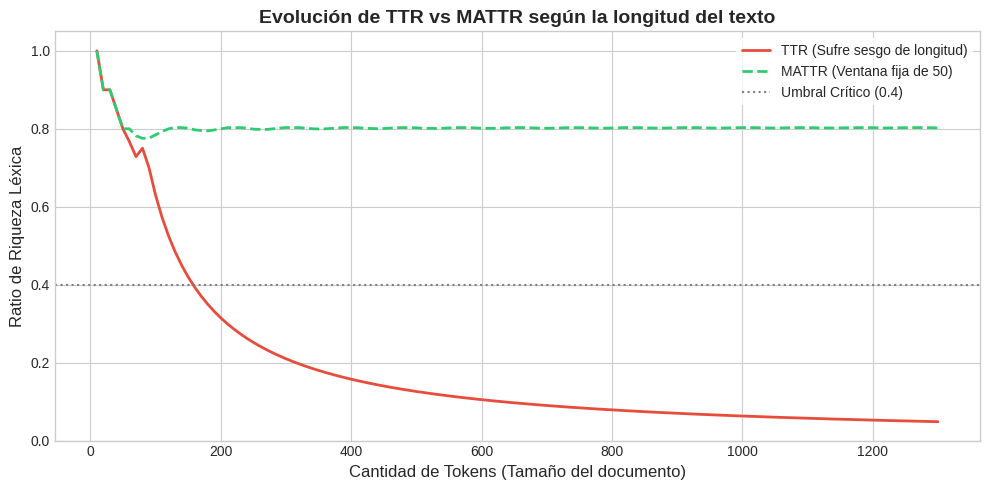

In [6]:
# =====================================================================
# 4. SIMULACIÓN DE CRECIMIENTO DE TEXTO (Evolución de Métricas)
# =====================================================================
# Multiplicamos el texto para simular un documento largo y observar el sesgo
tokens_largos = tokens_reales * 15

progreso_ttr = []
progreso_mattr = []
eje_x = range(10, len(tokens_largos), 10)

for limite in eje_x:
    sub_lista = tokens_largos[:limite]
    progreso_ttr.append(calcular_ttr(sub_lista))
    progreso_mattr.append(calcular_mattr(sub_lista, ventana=50))

# Graficar los resultados
plt.figure(figsize=(10, 5))
plt.plot(eje_x, progreso_ttr, label='TTR (Sufre sesgo de longitud)', color='#E74C3C', linewidth=2)
plt.plot(eje_x, progreso_mattr, label='MATTR (Ventana fija de 50)', color='#2ECC71', linewidth=2, linestyle='--')

plt.title('Evolución de TTR vs MATTR según la longitud del texto', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Tokens (Tamaño del documento)', fontsize=12)
plt.ylabel('Ratio de Riqueza Léxica', fontsize=12)
plt.axhline(y=0.4, color='gray', linestyle=':', label='Umbral Crítico (0.4)')
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

=== COMPARATIVA DE MÉTRICAS EN EL COLAB ===
                   Métrica Texto Original (Bruto) Texto Lematizado (Lemas)
            Tokens Totales                     87                       87
Types Únicos (Vocabulario)                     63                       56
                TTR Global                  0.724                    0.644
        MATTR (Ventana 30)                  0.864                    0.757




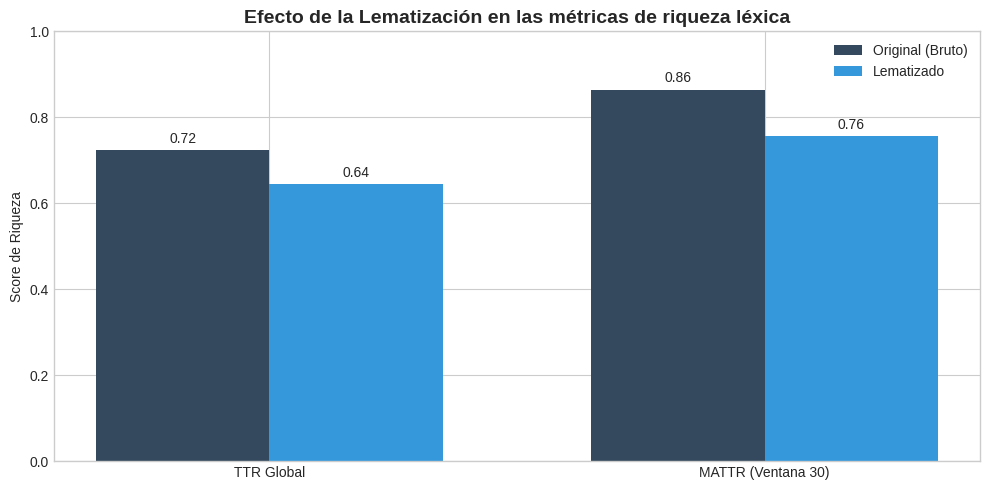

In [7]:
# =====================================================================
# 5. COMPARATIVA: TEXTO ORIGINAL VS TEXTO LEMATIZADO
# =====================================================================
# Calculamos métricas sobre el texto base
ttr_original = calcular_ttr(tokens_reales)
ttr_lematizado = calcular_ttr(lemas_reales)

mattr_original = calcular_mattr(tokens_reales, ventana=30)
mattr_lematizado = calcular_mattr(lemas_reales, ventana=30)

# Crear DataFrame para visualización tipo tabla en Colab
datos_comparativos = {
    "Métrica": ["Tokens Totales", "Types Únicos (Vocabulario)", "TTR Global", "MATTR (Ventana 30)"],
    "Texto Original (Bruto)": [len(tokens_reales), len(set(tokens_reales)), f"{ttr_original:.3f}", f"{mattr_original:.3f}"],
    "Texto Lematizado (Lemas)": [len(lemas_reales), len(set(lemas_reales)), f"{ttr_lematizado:.3f}", f"{mattr_lematizado:.3f}"]
}
df = pd.DataFrame(datos_comparativos)
print("=== COMPARATIVA DE MÉTRICAS EN EL COLAB ===")
print(df.to_string(index=False))
print("\n")

# Gráfico de barras para la PPT
categorias = ['TTR Global', 'MATTR (Ventana 30)']
valores_original = [ttr_original, mattr_original]
valores_lematizado = [ttr_lematizado, mattr_lematizado]

x = np.arange(len(categorias))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, valores_original, width, label='Original (Bruto)', color='#34495E')
rects2 = ax.bar(x + width/2, valores_lematizado, width, label='Lematizado', color='#3498DB')

ax.set_ylabel('Score de Riqueza')
ax.set_title('Efecto de la Lematización en las métricas de riqueza léxica', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categorias)
ax.set_ylim(0, 1.0)
ax.legend()

# Agregar los valores numéricos arriba de las barras
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
fig.tight_layout()
plt.show()

# Seccion 2 - Lematizacion

In [1]:
!python -m spacy download es_core_news_sm > /dev/null

import spacy
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA

nlp = spacy.load("es_core_news_sm")
plt.rcParams['figure.dpi'] = 100

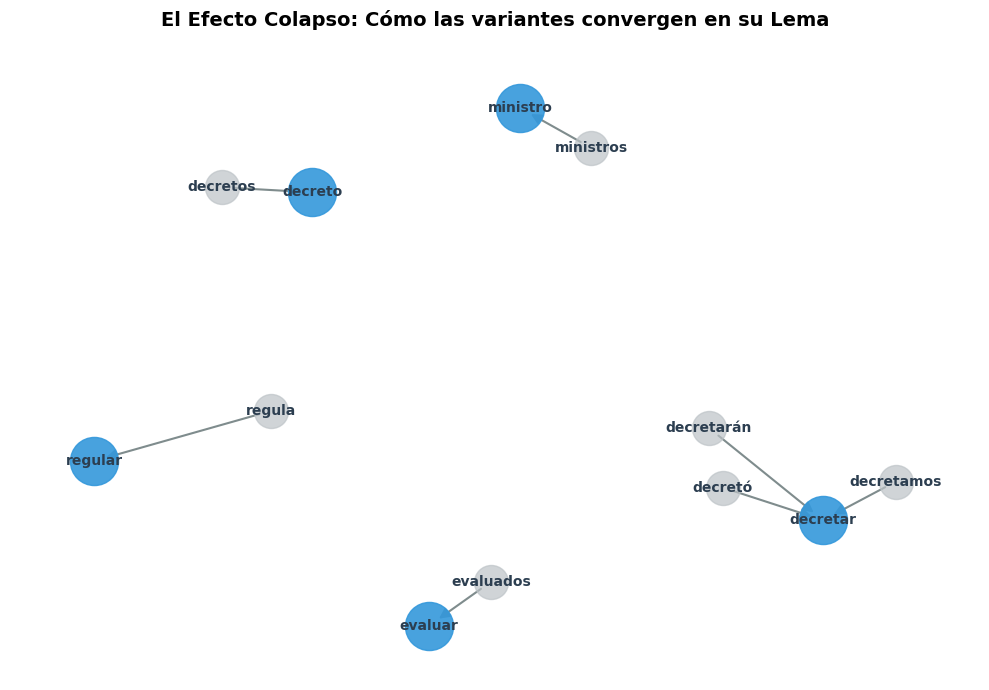

In [2]:
# =====================================================================
# VISUALIZACIÓN 1: GRAFO DE COLAPSO LÉXICO
# =====================================================================
texto_ejemplo = (
    "El presidente decretó la norma. Los ministros decretarán el gasto. "
    "Un decreto regula el presupuesto mientras otros decretos son evaluados. "
    "Ayer decretamos el cierre."
)

doc = nlp(texto_ejemplo.lower())

# Extraer pares (Token original -> Lema) excluyendo stop words y puntuación
conexiones = [(token.text, token.lemma_) for token in doc if token.is_alpha and not token.is_stop]

# Crear el grafo
G = nx.DiGraph()
for token, lema in conexiones:
    if token != lema: # Evitar bucles sobre el mismo nodo para limpiar la vista
        G.add_edge(token, lema)

# Configurar el diseño del gráfico (Estilo Fuerza/Spring)
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, k=0.5, iterations=50)

# Dibujar Nodos de los Lemas (Los centros de gravedad)
lemas_nodos = [nodo for nodo in G.nodes() if nodo in [l for t, l in conexiones]]
tokens_nodos = [nodo for nodo in G.nodes() if nodo not in lemas_nodos]

nx.draw_networkx_nodes(G, pos, nodelist=lemas_nodos, node_color='#3498DB', node_size=1200, alpha=0.9)
nx.draw_networkx_nodes(G, pos, nodelist=tokens_nodos, node_color='#BDC3C7', node_size=600, alpha=0.7)

# Dibujar etiquetas y flechas
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_color='#2C3E50')
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), edge_color='#7F8C8D', arrows=True, arrowsize=15, width=1.5)

plt.title("El Efecto Colapso: Cómo las variantes convergen en su Lema", fontsize=14, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

=== IMPACTO EN EL ESPACIO VECTORIAL ===
Dimensiones Vocabulario Original   (Columnas): 19 -> Términos: ['decretará', 'decretos', 'decretó', 'ejecutivo', 'el', 'general', 'la', 'las', 'los', 'mañana', 'modifican', 'nueva', 'nuevo', 'partidas', 'plan', 'poder', 'presupuestarias', 'resolución', 'secretario']
Dimensiones Vocabulario Lematizado (Columnas): 14 -> Términos: ['decretar', 'decreto', 'ejecutivo', 'el', 'general', 'mañana', 'modificar', 'nuevo', 'partida', 'plan', 'poder', 'presupuestaria', 'resolución', 'secretario']
¡Reducción del 26.3% del tamaño del espacio vectorial!



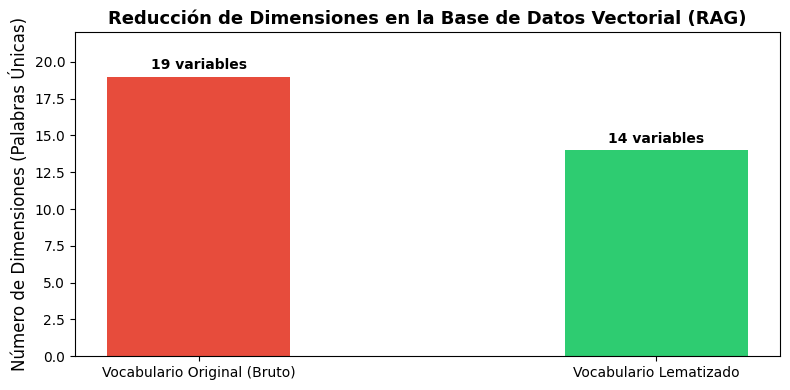

In [3]:
# =====================================================================
# VISUALIZACIÓN 2: REDUCCIÓN DE DIMENSIONALIDAD EN EL VOCABULARIO
# =====================================================================
# Simulamos 3 documentos/chunks legales cortos para un RAG
chunks_originales = [
    "El secretario decretó la nueva resolución general.",
    "Los decretos modifican las partidas presupuestarias.",
    "El poder ejecutivo decretará mañana el nuevo plan."
]

# Procesamos con spaCy para obtener las versiones lematizadas
chunks_lematizados = []
for chunk in chunks_originales:
    doc = nlp(chunk.lower())
    lemas = [token.lemma_ for token in doc if token.is_alpha]
    chunks_lematizados.append(" ".join(lemas))

# Creamos las matrices Bag of Words (Conteo de términos)
vec_orig = CountVectorizer()
vec_lema = CountVectorizer()

matriz_orig = vec_orig.fit_transform(chunks_originales).toarray()
matriz_lema = vec_lema.fit_transform(chunks_lematizados).toarray()

vocab_orig = vec_orig.get_feature_names_out()
vocab_lema = vec_lema.get_feature_names_out()

# Mostrar la reducción en consola
print("=== IMPACTO EN EL ESPACIO VECTORIAL ===")
print(f"Dimensiones Vocabulario Original   (Columnas): {len(vocab_orig)} -> Términos: {list(vocab_orig)}")
print(f"Dimensiones Vocabulario Lematizado (Columnas): {len(vocab_lema)} -> Términos: {list(vocab_lema)}")
print(f"¡Reducción del {((len(vocab_orig)-len(vocab_lema))/len(vocab_orig))*100:.1f}% del tamaño del espacio vectorial!\n")

# Gráfico comparativo de barras
fig, ax = plt.subplots(figsize=(8, 4))
barras = ax.bar(['Vocabulario Original (Bruto)', 'Vocabulario Lematizado'],
        [len(vocab_orig), len(vocab_lema)],
        color=['#E74C3C', '#2ECC71'], width=0.4)

ax.set_ylabel('Número de Dimensiones (Palabras Únicas)', fontsize=12)
ax.set_title('Reducción de Dimensiones en la Base de Datos Vectorial (RAG)', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(len(vocab_orig), len(vocab_lema)) + 3)

for barra in barras:
    height = barra.get_height()
    ax.annotate(f'{height} variables',
                xy=(barra.get_x() + barra.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()